11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🚀 Training model from scratch...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.6073 - loss: 1.3015 - val_accuracy: 0.9369 - val_loss: 0.2120
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 33ms/step - accuracy: 0.9477 - loss: 0.1723 - val_accuracy: 0.9561 - val_loss: 0.1456
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 32ms/step - accuracy: 0.9630 - loss: 0.1168 - val_accuracy: 0.9731 - val_loss: 0.0906
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9734 - loss: 0.0831 - val_accuracy: 0.9706 - val_loss: 0.0950
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 32ms/step - accuracy: 0.9761 - loss: 0.0780 - val_accuracy: 0.9741 - val_loss: 0.0814


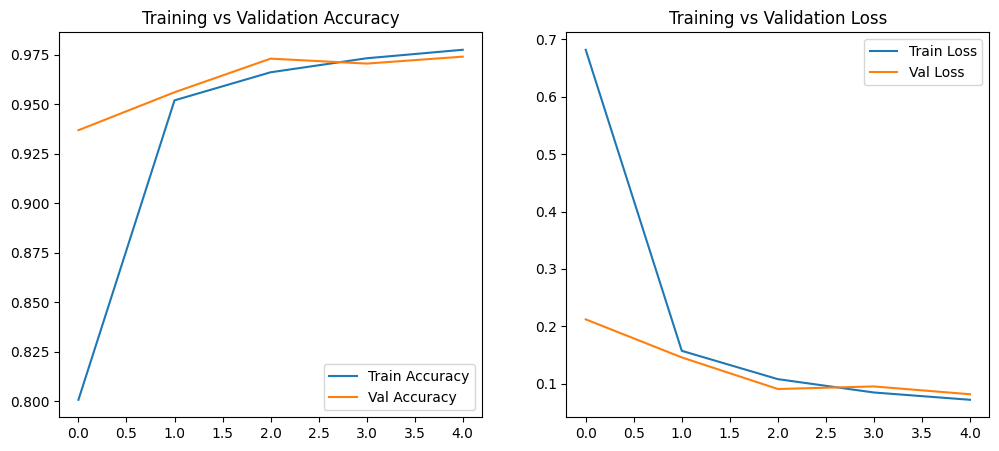

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9702 - loss: 0.0850
✅ Test accuracy: 0.9776
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


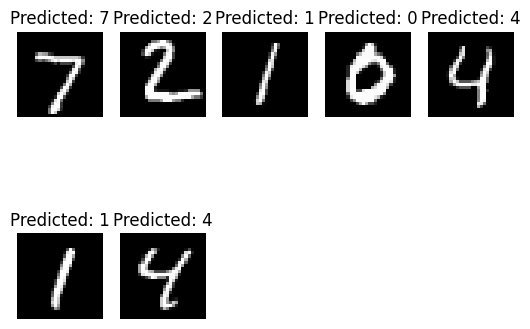

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

# Load MNIST dataset
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the data
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape the data for CNN input
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32")
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32")

# Split training data into train (80%) and validation (20%)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Define function to create model
def create_model():
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(64, (3,3), activation='relu'),
        keras.layers.MaxPooling2D((2,2)),
        keras.layers.Conv2D(64, (3,3), activation='relu'),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Path for saving the model
MODEL_PATH = "mnist_cnn_model.h5"

# Train or Load Model
if os.path.exists(MODEL_PATH):
    print("🔄 Loading saved model...")
    model = keras.models.load_model(MODEL_PATH)
else:
    print("🚀 Training model from scratch...")
    model = create_model()
    history = model.fit(x_train, y_train, epochs=5, validation_data=(x_val, y_val))  # Use validation set
    model.save(MODEL_PATH)

    # Plot accuracy and loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title("Training vs Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title("Training vs Validation Loss")
    plt.show()

# Evaluate model (using test set)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"✅ Test accuracy: {test_acc:.4f}")

# Predict multiple images
num_samples = 7  # Number of test samples to check
random_samples = x_test[:num_samples]  # Take first `num_samples` test images
predictions = model.predict(random_samples)
predicted_labels = np.argmax(predictions, axis=1)

# Display predictions
for i in range(num_samples):
    plt.subplot(2, 5, i+1)
    plt.imshow(random_samples[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis("off")
plt.show()

✅ Model loaded successfully!
Please upload one or more images:


Saving WhatsApp Image 2025-04-06 at 20.34.55.jpeg to WhatsApp Image 2025-04-06 at 20.34.55.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


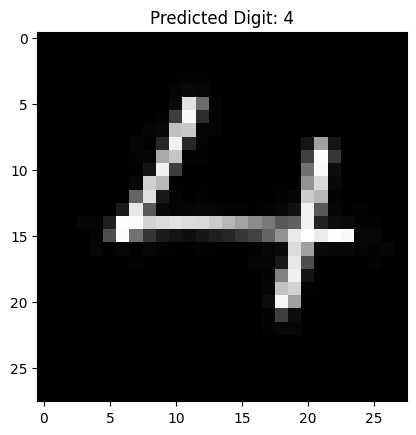

Image: WhatsApp Image 2025-04-06 at 20.34.55.jpeg, Predicted Digit: 4


In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from google.colab import files

# Load the trained model
MODEL_PATH = "mnist_cnn_model.h5"
if os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    print("✅ Model loaded successfully!")
else:
    print("❌ Model not found! Train the model first.")
    exit()

# Function to preprocess image
def preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    image = cv2.resize(image, (28, 28))  # Resize to 28x28
    image = 255 - image  # Invert colors (MNIST digits are white on black)
    image = np.array(image, dtype=np.float32) / 255.0  # Normalize
    image = image.reshape(1, 28, 28, 1)  # Reshape for CNN input
    return image, image.squeeze()  # Return both normalized and processed images

# Upload and predict multiple images
print("Please upload one or more images:")
uploaded = files.upload()

for image_path in uploaded.keys():
    image, processed_image = preprocess_image(image_path)  # Preprocess the image
    prediction = model.predict(image)
    predicted_label = int(np.argmax(prediction))

    # Display the processed image
    plt.imshow(processed_image, cmap='gray')
    plt.title(f"Predicted Digit: {predicted_label}")
    plt.show()

    print(f"Image: {image_path}, Predicted Digit: {predicted_label}")